The goal of this notebook is to derive the Maximum Shortest Path Length (MSPL) for the OG, known also as the diameter of the graph. We are going to explain why we resorted to a heuristic method, as well as prove that this approximation is very close to the real values of the MSPL. In contrast with the ASPL case we have calculated the approximate data in a separate file, in this case, it is a part of ```real_join_data.py```.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from data_analysis_functions import *
import os
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path

In [6]:
#Setup assumed 
n=7
d=3

In [9]:
g = nx.read_edgelist(f"orbits_d{d}_n{n}_separated_sorted/orbit_55", nodetype=int)
print("Number of nodes:",len(list(g.nodes())))
print("Number of edges",len(list(g.edges())))

Number of nodes: 5016
Number of edges 43848


In [10]:
nx.diameter(g)

7

It becomes obvious that we can calculate some of the diameters exactly with the networkx built-in function. Calculate up to n = 6.

In [12]:
exact_og_diameters = []
n = 6
for cnt in range(3,n+1):
    files_for_given_orbit = os.listdir(f"orbits_d{d}_n{cnt}_separated_sorted")
    files_for_given_orbit.sort(key=lambda x: int(x.split('_')[-1]))  # Sort the list based on the orbit number
    for file in files_for_given_orbit:
        print(f"Starting orbits_d{d}_n{cnt}_separated_sorted/{file}")
        g = nx.read_edgelist(f"orbits_d{d}_n{cnt}_separated_sorted/{file}", nodetype=int)
        temp = nx.diameter(g)
        exact_og_diameters.append(temp)    

Starting orbits_d3_n3_separated_sorted/orbit_0
Starting orbits_d3_n4_separated_sorted/orbit_0
Starting orbits_d3_n4_separated_sorted/orbit_1
Starting orbits_d3_n4_separated_sorted/orbit_2
Starting orbits_d3_n5_separated_sorted/orbit_0
Starting orbits_d3_n5_separated_sorted/orbit_1
Starting orbits_d3_n5_separated_sorted/orbit_2
Starting orbits_d3_n5_separated_sorted/orbit_3
Starting orbits_d3_n5_separated_sorted/orbit_4
Starting orbits_d3_n6_separated_sorted/orbit_0
Starting orbits_d3_n6_separated_sorted/orbit_1
Starting orbits_d3_n6_separated_sorted/orbit_2
Starting orbits_d3_n6_separated_sorted/orbit_3
Starting orbits_d3_n6_separated_sorted/orbit_4
Starting orbits_d3_n6_separated_sorted/orbit_5
Starting orbits_d3_n6_separated_sorted/orbit_6
Starting orbits_d3_n6_separated_sorted/orbit_7
Starting orbits_d3_n6_separated_sorted/orbit_8
Starting orbits_d3_n6_separated_sorted/orbit_9
Starting orbits_d3_n6_separated_sorted/orbit_10
Starting orbits_d3_n6_separated_sorted/orbit_11
Starting or

In [15]:
create_file = False

if create_file:
    with open('og_data_final/exact_og_diameters_till_n_6.txt', 'w') as f:
        f.write(str(exact_og_diameters))   
        
print('Number of orbits the diameter was exactly calculated:',len(exact_og_diameters))

Number of orbits the diameter was exactly calculated: 30


Include n = 7.

In [17]:
exact_og_diameters_more_6 = []
n = 7
for cnt in range(3,n+1):
    files_for_given_orbit = os.listdir(f"orbits_d{d}_n{cnt}_separated_sorted")
    files_for_given_orbit.sort(key=lambda x: int(x.split('_')[-1]))  # Sort the list based on the orbit number
    for file in files_for_given_orbit:
        file_size_mb = os.path.getsize(f"orbits_d{d}_n{cnt}_separated_sorted/{file}") / (1024 * 1024)
        if file_size_mb <= 5:
            print(f"Starting orbits_d{d}_n{cnt}_separated_sorted/{file}")
            g = nx.read_edgelist(f"orbits_d{d}_n{cnt}_separated_sorted/{file}", nodetype=int)
            temp = nx.diameter(g)
            exact_og_diameters_more_6.append(temp)  
        else:
            print(f"Skipping orbits_d{d}_n{cnt}_separated_sorted/{file} due size. Zero assinged")
            exact_og_diameters_more_6.append(0)
            

Starting orbits_d3_n3_separated_sorted/orbit_0
Starting orbits_d3_n4_separated_sorted/orbit_0
Starting orbits_d3_n4_separated_sorted/orbit_1
Starting orbits_d3_n4_separated_sorted/orbit_2
Starting orbits_d3_n5_separated_sorted/orbit_0
Starting orbits_d3_n5_separated_sorted/orbit_1
Starting orbits_d3_n5_separated_sorted/orbit_2
Starting orbits_d3_n5_separated_sorted/orbit_3
Starting orbits_d3_n5_separated_sorted/orbit_4
Starting orbits_d3_n6_separated_sorted/orbit_0
Starting orbits_d3_n6_separated_sorted/orbit_1
Starting orbits_d3_n6_separated_sorted/orbit_2
Starting orbits_d3_n6_separated_sorted/orbit_3
Starting orbits_d3_n6_separated_sorted/orbit_4
Starting orbits_d3_n6_separated_sorted/orbit_5
Starting orbits_d3_n6_separated_sorted/orbit_6
Starting orbits_d3_n6_separated_sorted/orbit_7
Starting orbits_d3_n6_separated_sorted/orbit_8
Starting orbits_d3_n6_separated_sorted/orbit_9
Starting orbits_d3_n6_separated_sorted/orbit_10
Starting orbits_d3_n6_separated_sorted/orbit_11
Starting or

In [18]:
np.count_nonzero(exact_og_diameters_more_6)

with open("og_data_final/exact_og_diameters_more_6_5mb.txt", "w") as f:
        f.write(str(exact_og_diameters_more_6))

In [19]:
print('Number of orbits the diameter was exactly calculated:',np.count_nonzero(exact_og_diameters_more_6))

Number of orbits the diameter was exactly calculated: 79


Plot exact up to 5 Mb.

Mean: 4.5243
Standard Deviation: 2.7654


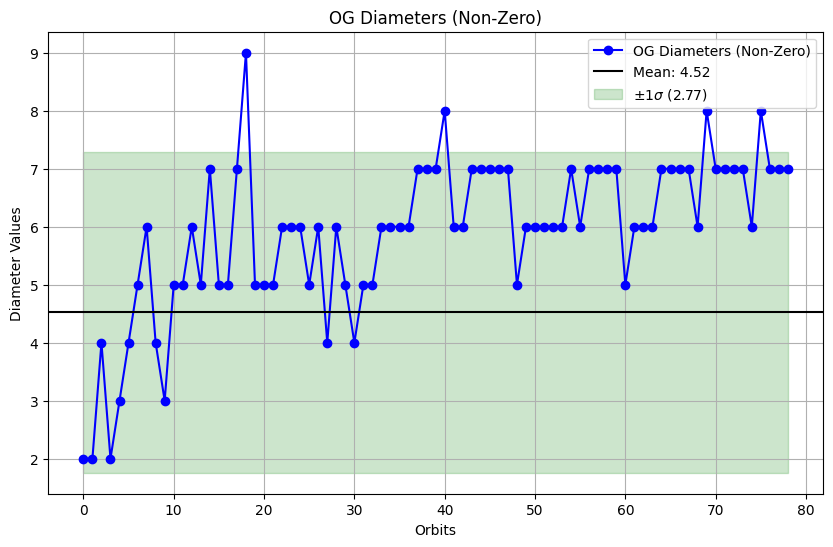

In [23]:
with open("og_data_final/exact_og_diameters_more_6_5mb.txt", "r") as f:
    exact_diam_7_uo_to_5_mb = eval(f.read())
    

# Step 2: Calculate mean and standard deviation
mean_value = np.mean(exact_diam_7_uo_to_5_mb)
std_value = np.std(exact_diam_7_uo_to_5_mb)

print(f"Mean: {mean_value:.4f}")
print(f"Standard Deviation: {std_value:.4f}")

# Step 3: Mask zero values
non_zero_mask = np.array(exact_diam_7_uo_to_5_mb) != 0
filtered_data = np.array(exact_diam_7_uo_to_5_mb)[non_zero_mask]

# Step 4: Plot the data without error bars
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(filtered_data)), filtered_data, 'o-', label='OG Diameters (Non-Zero)', color='blue')

# Add mean and error range
plt.axhline(y=mean_value, color='black', linestyle='-', label=f'Mean: {mean_value:.2f}')
plt.fill_between(np.arange(len(filtered_data)), mean_value - std_value, mean_value + std_value, color='green', alpha=0.2, label=f'±1$\\sigma$ ({std_value:.2f})')

# Labels and title
plt.xlabel('Orbits')
plt.ylabel('Diameter Values')
plt.title('OG Diameters (Non-Zero)')
plt.legend()

# Ensure y-axis shows every integer
plt.yticks(np.arange(int(np.min(filtered_data)), int(np.max(filtered_data)) + 1, 1))
plt.grid(True, axis='y')
plt.grid(True, axis='x')

# Display the plot
plt.show()



Residuals for up to 6. Expect no difference since we cover everything with the sampling.

Mean of Residuals: 0.0000%
Standard Deviation of Residuals: 0.0000%


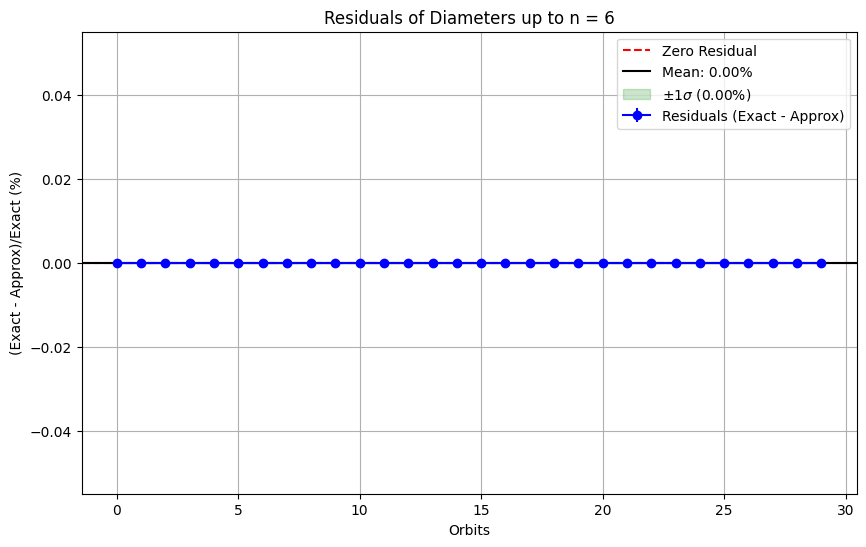

In [24]:
# Load the data
with open("og_data/exact_og_diameters_till_n_6.txt", "r") as f:
    exact_diam_up_6 = eval(f.read())

with open("og_data/mc_1000_og_diameters_more_6.txt", "r") as f:
    approx_diam_up_6 = eval(f.read())

# Convert lists to arrays
exact_diam_up_6 = np.array(exact_diam_up_6)
approx_diam_up_6 = np.array(approx_diam_up_6)

# Create a mask to exclude cases where exact_diam_up_6 is 0
mask = exact_diam_up_6 != 0

# Calculate residuals
residuals = (exact_diam_up_6[mask] - approx_diam_up_6[mask]) * 100 / exact_diam_up_6[mask]

# Save residuals to a file if needed
create_file = False  # Set to True if you want to save the file
if create_file:
    with open('og_data/residuals_diameters_up_6.txt', 'w') as f:
        f.write(str(residuals))

# Calculate statistics for the residuals
mean_residuals = np.mean(residuals)
std_residuals = np.std(residuals)

print(f"Mean of Residuals: {mean_residuals:.4f}%")
print(f"Standard Deviation of Residuals: {std_residuals:.4f}%")

# Plot the residuals with error bars
plt.figure(figsize=(10, 6))
plt.errorbar(np.arange(len(residuals)), residuals, yerr=std_residuals, fmt='o-', label='Residuals (Exact - Approx)', color='blue')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual')

# Add mean and error range
plt.axhline(y=mean_residuals, color='black', linestyle='-', label=f'Mean: {mean_residuals:.2f}%')
plt.fill_between(np.arange(len(residuals)), mean_residuals - std_residuals, mean_residuals + std_residuals, color='green', alpha=0.2, label=f'±1$\sigma$ ({std_residuals:.2f}%)')

# Labels and title
plt.xlabel('Orbits')
plt.ylabel('(Exact - Approx)/Exact (%)')
plt.title('Residuals of Diameters up to n = 6')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

Residuals for n = 7

In [26]:
# Load the data
with open("og_data_final/mc_1000_og_diameters_n7.txt", "r") as f:
    approx_diam_all = eval(f.read())

with open("og_data_final/exact_og_diameters_more_6_5mb.txt", "r") as f:
    exact_diam_all = eval(f.read())
    
# Ensure both arrays have the same length
exact_diam_all = np.array(exact_diam_all)
approx_diam_all = np.array(approx_diam_all)

print(approx_diam_all)
print(exact_diam_all)

[2 2 4 2 3 4 5 6 4 3 5 5 6 5 7 5 5 7 9 5 5 5 6 6 6 5 6 4 6 5 4 5 5 6 6 6 6
 7 7 7 8 6 6 7 7 7 7 7 8 8 8 5 6 6 6 6 6 7 6 7 7 7 8 7 9 8 8 8 5 6 6 6 7 7
 7 7 7 8 7 8 9 6 8 9 7 7 9 9 8 7 7 6 8 8 8 7 8 8 9 8 7 7 7]
[2 2 4 2 3 4 5 6 4 3 5 5 6 5 7 5 5 7 9 5 5 5 6 6 6 5 6 4 6 5 4 5 5 6 6 6 6
 7 7 7 8 6 6 7 7 7 7 7 0 0 0 5 6 6 6 6 6 7 6 7 7 7 0 7 0 0 0 0 5 6 6 6 0 7
 0 7 7 0 7 0 0 6 8 0 7 7 0 0 0 7 7 6 8 0 0 7 0 0 0 0 0 7 7]


Mean of Residuals: 0.0000%
Standard Deviation of Residuals: 0.0000%


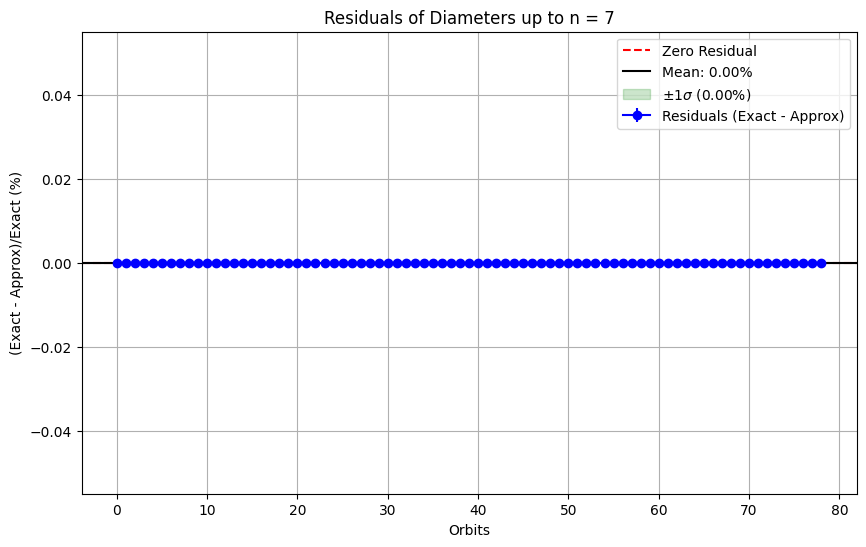

In [27]:
if exact_diam_all.shape != approx_diam_all.shape:
    min_length = min(len(exact_diam_all), len(approx_diam_all))
    exact_diam_all = exact_diam_all[:min_length]
    approx_diam_all = approx_diam_all[:min_length]

# Create a mask to exclude positions where exact_diam_all is 0
mask = exact_diam_all != 0

# Apply the mask to both arrays
exact_filtered = exact_diam_all[mask]
approx_filtered = approx_diam_all[mask]

# Calculate residuals only for valid positions
residuals = (exact_filtered - approx_filtered) * 100 / exact_filtered

# Save residuals to a file if needed
create_file = False  # Set to True if you want to save the file
if create_file:
    with open('og_data_final/residuals_diameters_all.txt', 'w') as f:
        f.write(str(residuals.tolist()))

# Calculate statistics for the residuals
mean_residuals = np.mean(residuals)
std_residuals = np.std(residuals)

print(f"Mean of Residuals: {mean_residuals:.4f}%")
print(f"Standard Deviation of Residuals: {std_residuals:.4f}%")

# Plot the residuals with error bars
plt.figure(figsize=(10, 6))
plt.errorbar(np.arange(len(residuals)), residuals, yerr=std_residuals, fmt='o-', label='Residuals (Exact - Approx)', color='blue')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual')

# Add mean and error range
plt.axhline(y=mean_residuals, color='black', linestyle='-', label=f'Mean: {mean_residuals:.2f}%')
plt.fill_between(np.arange(len(residuals)), mean_residuals - std_residuals, mean_residuals + std_residuals, color='green', alpha=0.2, label=f'±1$\sigma$ ({std_residuals:.2f}%)')

# Labels and title
plt.xlabel('Orbits')
plt.ylabel('(Exact - Approx)/Exact (%)')
plt.title('Residuals of Diameters up to n = 7')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()


Our approximation finds exactly the same values as the exact value. So we can just use the approximate data since they perfectly agree with the real ones.

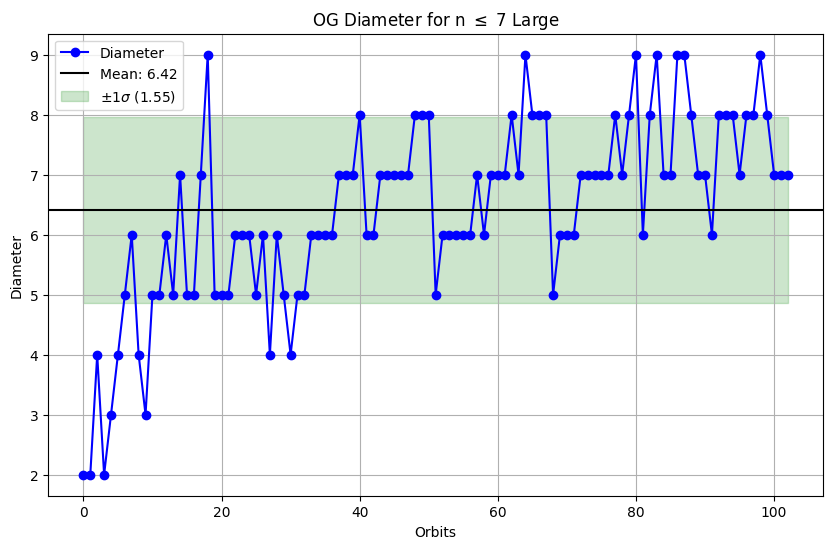

In [30]:
# Calculate mean and standard deviation
mean_aspl = np.mean(approx_diam_all)
std_aspl = np.std(approx_diam_all)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(approx_diam_all, 'o-', label='Diameter', color='blue')

# Add mean line and ±1σ range
plt.axhline(y=mean_aspl, color='black', linestyle='-', label=f'Mean: {mean_aspl:.2f}')
plt.fill_between(np.arange(len(approx_diam_all)), mean_aspl - std_aspl, mean_aspl + std_aspl,
                 color='green', alpha=0.2, label=f'±1$\sigma$ ({std_aspl:.2f})')

# Labels and title
plt.xlabel('Orbits')
plt.ylabel('Diameter')
plt.title('OG Diameter for n $\leq$ 7 Large')
plt.legend()
plt.grid(True)


# Display the plot
plt.show()